In [1]:
import numpy as np
import pandas as pd
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

from pyfrechet.metric_spaces import MetricData, Euclidean, two_euclidean
from pyfrechet.regression.bagged_regressor import BaggedRegressor
from sklearn.preprocessing import MinMaxScaler
import multiprocessing as mp
import matplotlib.lines as mlines
import sys
import time

INFO: Using numpy backend


In [2]:
def pb_radius_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'radius'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'pb_volume_results')):
        if file.endswith('.npy'):
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'pb_volume_results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'radius': [result['radius']],
            'dim': file.split('_')[3]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    return coverage_df

def pb_vol_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'volume'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'pb_volume_results')):
        if file.endswith('.npy'):
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'pb_volume_results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'volume': [result['volume']],
            'dim': file.split('_')[3]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    return coverage_df

def pb_all_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'radius'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'pb_volume_results')):
        if file.endswith('.npy'):
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'pb_volume_results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'radius': [result['radius']],
            'volume': [result['volume']],
            'dim': file.split('_')[3]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    return coverage_df

def conf_radius_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'radius'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conf_volume_results')):
        if file.endswith('.npy'):
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conf_volume_results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'radius': [result['radius']],
            'dim': file.split('_')[3]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    return coverage_df

def conf_vol_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'volume'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conf_volume_results')):
        if file.endswith('.npy'):
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conf_volume_results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'volume': [result['volume']],
            'dim': file.split('_')[3]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    return coverage_df

def conf_all_results():
    """ Compute empirical OOB_quantile for different confidence levels. """
    coverage_df = pd.DataFrame(columns=['sample_index', 'radius'])
    i = 0
    for file in os.listdir(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conf_volume_results')):
        if file.endswith('.npy'):
            i+=1
            infile=open(os.path.join(os.path.join(os.getcwd(), 'simulations_euc'), 'conf_volume_results/' + file), 'rb')
            result=np.load(infile, allow_pickle=True).item()
            infile.close()
        else:
            continue
        coverage_df = pd.concat([coverage_df, pd.DataFrame({
            'sample_index': int(file.split('_')[1][4:]),
            'radius': [result['radius']],  
            'volume': [result['volume']],
            'dim': file.split('_')[3]
        }, index=pd.RangeIndex(0, 1))], ignore_index=True)

    return coverage_df


In [3]:
pb_radius_df = pb_radius_results()
pb_vol_df = pb_vol_results()

conf_radius_df = conf_radius_results()
conf_vol_df = conf_vol_results()

In [4]:
pb_radius_df_alpha_01 = pb_radius_df.copy()
pb_radius_df_alpha_05 = pb_radius_df.copy()
pb_radius_df_alpha_1 = pb_radius_df.copy()

pb_vol_df_alpha_01 = pb_vol_df.copy()
pb_vol_df_alpha_05 = pb_vol_df.copy()
pb_vol_df_alpha_1 = pb_vol_df.copy()

pb_radius_df_alpha_01['radius'] = pb_radius_df['radius'].apply(lambda x: x[0])
pb_radius_df_alpha_05['radius'] = pb_radius_df['radius'].apply(lambda x: x[1])
pb_radius_df_alpha_1['radius'] = pb_radius_df['radius'].apply(lambda x: x[2])

pb_vol_df_alpha_01['volume'] = pb_vol_df['volume'].apply(lambda x: x[0])
pb_vol_df_alpha_05['volume'] = pb_vol_df['volume'].apply(lambda x: x[1])
pb_vol_df_alpha_1['volume'] = pb_vol_df['volume'].apply(lambda x: x[2])

conf_radius_df_alpha_01 = conf_radius_df.copy()
conf_radius_df_alpha_05 = conf_radius_df.copy()
conf_radius_df_alpha_1 = conf_radius_df.copy()

conf_radius_df_alpha_01['radius'] = conf_radius_df['radius'].apply(lambda x: x[0])
conf_radius_df_alpha_05['radius'] = conf_radius_df['radius'].apply(lambda x: x[1])
conf_radius_df_alpha_1['radius'] = conf_radius_df['radius'].apply(lambda x: x[2])


conf_vol_df_alpha_01 = conf_vol_df.copy()
conf_vol_df_alpha_05 = conf_vol_df.copy()
conf_vol_df_alpha_1 = conf_vol_df.copy()

conf_vol_df_alpha_01['volume'] = conf_vol_df['volume'].apply(lambda x: x[0])
conf_vol_df_alpha_05['volume'] = conf_vol_df['volume'].apply(lambda x: x[1])
conf_vol_df_alpha_1['volume'] = conf_vol_df['volume'].apply(lambda x: x[2])

conf_vol_df_alpha_01.head()
conf_vol_df_alpha_05.head()
conf_vol_df_alpha_1.head()

,sample_index,volume,dim
0,341,2.886071e+07,10
1,241,1.120482e+04,5
2,232,1.300111e+09,10
3,412,6.379831e+03,5
4,104,4.612449e+00,1


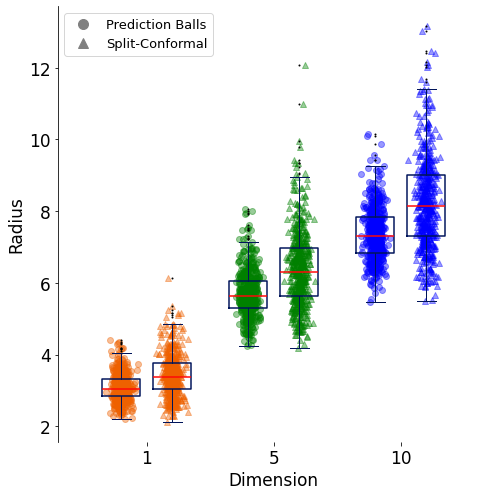

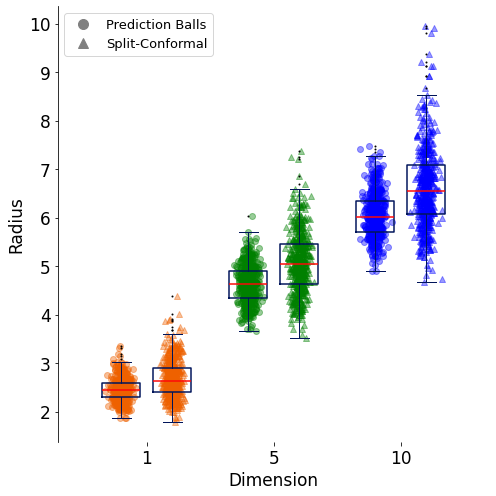

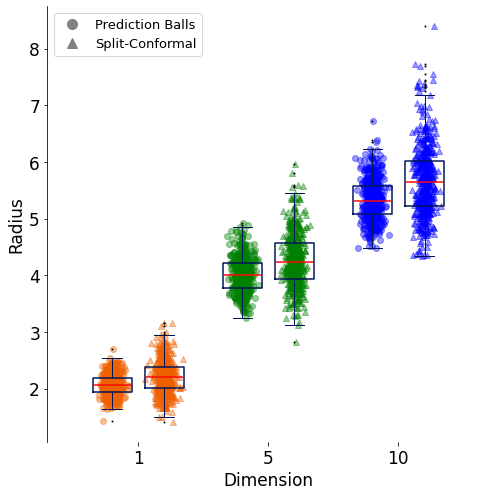

In [5]:
def radius_compare_pb_sc_dimension(pb_data, sc_data, save_path):
    """
    Compare Prediction Ball (PB) and Split-Conformal (SC) across different dimensions.

    Parameters:
        pb_data (DataFrame): DataFrame containing PB radius or volume.
        sc_data (DataFrame): DataFrame containing SC radius or volume.
        metric (str): 'radius' or 'volume' to determine what is plotted.
        save_path (str): Path to save the generated plots.
    """
    for pb_data, sc_data, alpha_level in zip(
    [pb_radius_df_alpha_01, pb_radius_df_alpha_05, pb_radius_df_alpha_1], 
    [conf_radius_df_alpha_01, conf_radius_df_alpha_05, conf_radius_df_alpha_1], 
    [0.01, 0.05, 0.1] ):
        ##### Set style options #####
        boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
        flierprops = dict(marker='o', markersize=1, linestyle='none')
        whiskerprops = dict(color='#00145A')
        capprops = dict(color='#00145A')
        medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

        # Extract unique dimensions
        dims = sorted(pb_data['dim'].astype(int).unique())

        fig = plt.figure(facecolor="white", figsize=(7, 7))
        ax = fig.add_subplot(111)

        # Prepare boxplot data
        pb_boxplot_data = [pb_data[pb_data['dim'].astype(int) == d]['radius'].values for d in dims]
        sc_boxplot_data = [sc_data[sc_data['dim'].astype(int) == d]['radius'].values for d in dims]
        # Set positions for PB and SC boxplots
        positions_pb = np.array(range(len(dims))) - 0.2
        positions_sc = np.array(range(len(dims))) + 0.2

        # Boxplots for PB and SC
        ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
                boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                flierprops=flierprops, medianprops=medianprops, showmeans=False)
        ax.boxplot(sc_boxplot_data, positions=positions_sc, widths=0.3, notch=False, 
                boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                flierprops=flierprops, medianprops=medianprops, showmeans=False)

        # Scatter plot for individual points
        palette = ['#ee6100', 'g', 'b']  # Colors for each dimension

        for i, d in enumerate(dims):
            xs_pb = np.random.normal(positions_pb[i], 0.04, len(pb_boxplot_data[i]))
            xs_sc = np.random.normal(positions_sc[i], 0.04, len(sc_boxplot_data[i]))

            ax.scatter(xs_pb, pb_boxplot_data[i], alpha=0.4, color=palette[i], label='Prediction Balls' if i == 0 else "")
            ax.scatter(xs_sc, sc_boxplot_data[i], alpha=0.4, color=palette[i], marker='^', label='Split-Conformal' if i == 0 else "")

        sns.despine(bottom=True)  # Remove right and top axis lines

        ax.set_xticks(range(len(dims)))
        ax.set_xticklabels([str(d) for d in dims], fontsize=17)

        ax.set_xlabel('Dimension', fontsize=17)
        ax.set_ylabel('Radius', fontsize=17)
        ax.tick_params(labelsize=17)
        ax.grid(False)

        # Legend
        legend_handles = [
            mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction Balls'),
            mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-Conformal')
        ]
        ax.legend(handles=legend_handles, loc='upper left', fontsize=13)

        fig.tight_layout()
        filename = os.path.join(save_path, f'simulations_euc/dim_pb_vs_conf_radius_{str(alpha_level)[2:]}.pdf')
        fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
        plt.show()



# Ensure 'dim' is numeric
pb_radius_df['dim'] = pb_radius_df['dim'].astype(int)
conf_radius_df['dim'] = conf_radius_df['dim'].astype(int)
save_path = os.path.join(os.getcwd())
# Generate plots for both radius and volume
radius_compare_pb_sc_dimension(pb_radius_df, conf_radius_df, save_path=save_path)

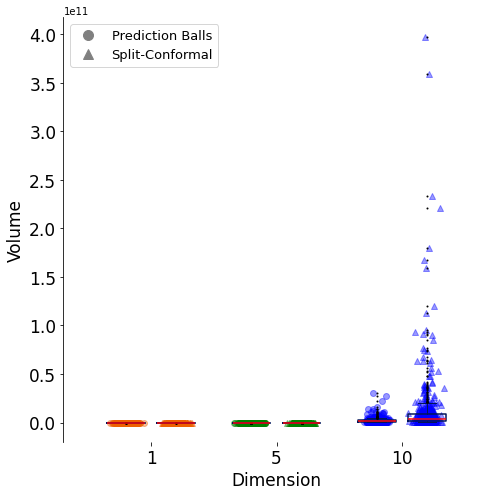

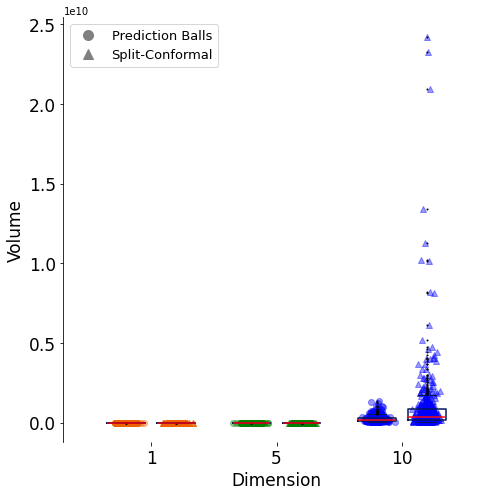

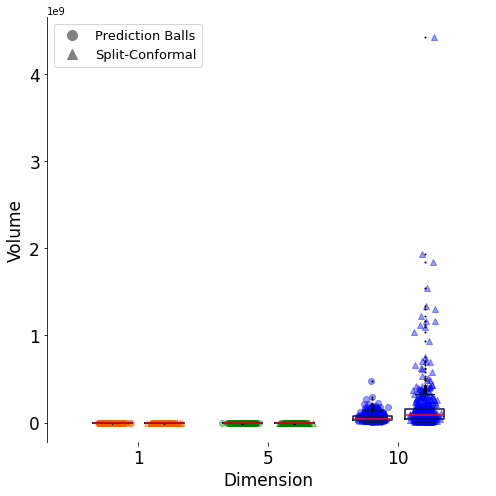

In [6]:
def volume_compare_pb_sc_dimension(pb_data, sc_data, save_path):
    """
    Compare Prediction Ball (PB) and Split-Conformal (SC) across different dimensions.

    Parameters:
        pb_data (DataFrame): DataFrame containing PB volume.
        sc_data (DataFrame): DataFrame containing SC volume.
        save_path (str): Path to save the generated plots.
    """
    for pb_data, sc_data, alpha_level in zip(
    [pb_vol_df_alpha_01, pb_vol_df_alpha_05, pb_vol_df_alpha_1], 
    [conf_vol_df_alpha_01, conf_vol_df_alpha_05, conf_vol_df_alpha_1], 
    [0.01, 0.05, 0.1] ):
        ##### Set style options #####
        boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
        flierprops = dict(marker='o', markersize=1, linestyle='none')
        whiskerprops = dict(color='#00145A')
        capprops = dict(color='#00145A')
        medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

        # Extract unique dimensions
        dims = sorted(pb_data['dim'].astype(int).unique())

        fig = plt.figure(facecolor="white", figsize=(7, 7))
        ax = fig.add_subplot(111)

        # Prepare boxplot data
        pb_boxplot_data = [pb_data[pb_data['dim'].astype(int) == d]['volume'].values for d in dims]
        sc_boxplot_data = [sc_data[sc_data['dim'].astype(int) == d]['volume'].values for d in dims]
        # Set positions for PB and SC boxplots
        positions_pb = np.array(range(len(dims))) - 0.2
        positions_sc = np.array(range(len(dims))) + 0.2

        # Boxplots for PB and SC
        ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
                boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                flierprops=flierprops, medianprops=medianprops, showmeans=False)
        ax.boxplot(sc_boxplot_data, positions=positions_sc, widths=0.3, notch=False, 
                boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                flierprops=flierprops, medianprops=medianprops, showmeans=False)

        # Scatter plot for individual points
        palette = ['#ee6100', 'g', 'b']  # Colors for each dimension

        for i, d in enumerate(dims):
            xs_pb = np.random.normal(positions_pb[i], 0.04, len(pb_boxplot_data[i]))
            xs_sc = np.random.normal(positions_sc[i], 0.04, len(sc_boxplot_data[i]))

            ax.scatter(xs_pb, pb_boxplot_data[i], alpha=0.4, color=palette[i], label='Prediction Balls' if i == 0 else "")
            ax.scatter(xs_sc, sc_boxplot_data[i], alpha=0.4, color=palette[i], marker='^', label='Split-Conformal' if i == 0 else "")
        sns.despine(bottom=True)  # Remove right and top axis lines

        ax.set_xticks(range(len(dims)))
        ax.set_xticklabels([str(d) for d in dims], fontsize=17)

        ax.set_xlabel('Dimension', fontsize=17)
        ax.set_ylabel('Volume', fontsize=17)
        ax.tick_params(labelsize=17)
        ax.grid(False)

        # Legend
        legend_handles = [
            mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction Balls'),
            mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-Conformal')
        ]
        ax.legend(handles=legend_handles, loc='upper left', fontsize=13)

        fig.tight_layout()
        filename = os.path.join(save_path, f'simulations_euc/dim_pb_vs_conf_volume_{str(alpha_level)[2:]}.pdf')
        fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
        plt.show()


# Ensure 'dim' is numeric
pb_vol_df['dim'] = pb_vol_df['dim'].astype(int)
conf_vol_df['dim'] = conf_vol_df['dim'].astype(int)
save_path = os.path.join(os.getcwd())
# Generate plots for volume
volume_compare_pb_sc_dimension(pb_vol_df, conf_vol_df, save_path=save_path)

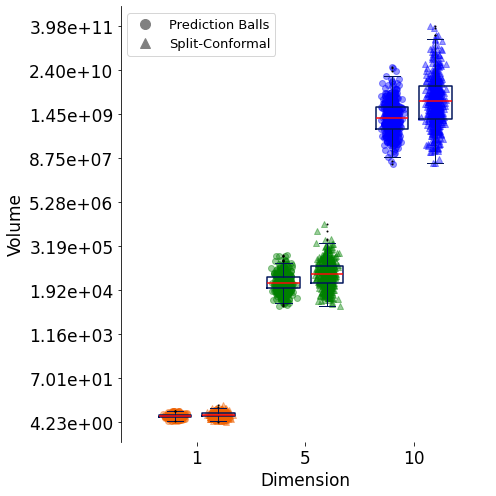

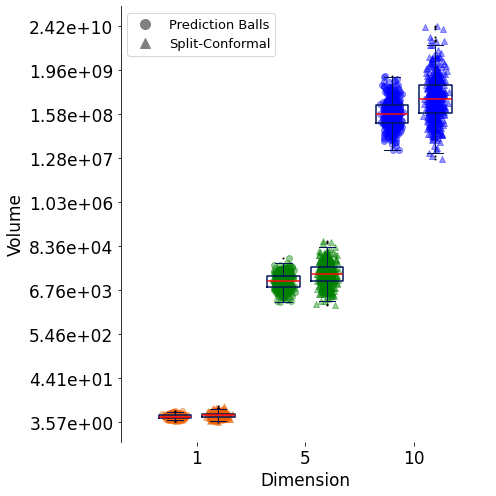

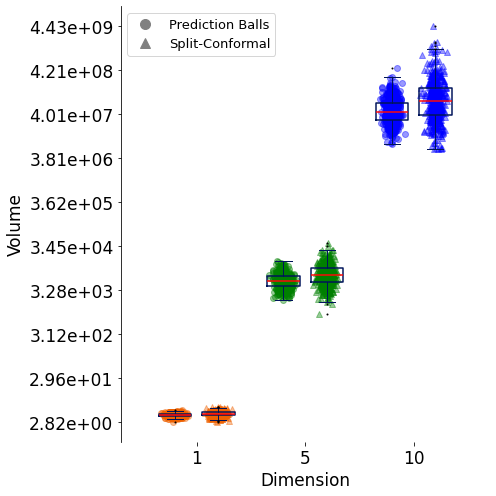

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.lines as mlines

def volume_compare_pb_sc_dimension(pb_data, sc_data, save_path):
    """
    Compare Prediction Ball (PB) and Split-Conformal (SC) across different dimensions,
    with a logarithmic scale on the y-axis while displaying original values.
    """
    for pb_data, sc_data, alpha_level in zip(
        [pb_vol_df_alpha_01, pb_vol_df_alpha_05, pb_vol_df_alpha_1], 
        [conf_vol_df_alpha_01, conf_vol_df_alpha_05, conf_vol_df_alpha_1], 
        [0.01, 0.05, 0.1]
    ):
        ##### Set style options #####
        boxprops = dict(linestyle='-', linewidth=1.5, color='#00145A')
        flierprops = dict(marker='o', markersize=1, linestyle='none')
        whiskerprops = dict(color='#00145A')
        capprops = dict(color='#00145A')
        medianprops = dict(linewidth=1.5, linestyle='-', color='#ff0808')

        # Extract unique dimensions
        dims = sorted(pb_data['dim'].astype(int).unique())

        fig = plt.figure(facecolor="white", figsize=(7, 7))
        ax = fig.add_subplot(111)

        # Apply log10 transformation
        pb_boxplot_data = [np.log10(pb_data[pb_data['dim'].astype(int) == d]['volume'].values) for d in dims]
        sc_boxplot_data = [np.log10(sc_data[sc_data['dim'].astype(int) == d]['volume'].values) for d in dims]

        # Set positions for PB and SC boxplots
        positions_pb = np.array(range(len(dims))) - 0.2
        positions_sc = np.array(range(len(dims))) + 0.2

        # Boxplots for PB and SC (log-transformed)
        ax.boxplot(pb_boxplot_data, positions=positions_pb, widths=0.3, notch=False, 
                   boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                   flierprops=flierprops, medianprops=medianprops, showmeans=False)
        ax.boxplot(sc_boxplot_data, positions=positions_sc, widths=0.3, notch=False, 
                   boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, 
                   flierprops=flierprops, medianprops=medianprops, showmeans=False)

        # Scatter plot for individual points
        palette = ['#ee6100', 'g', 'b']

        for i, d in enumerate(dims):
            xs_pb = np.random.normal(positions_pb[i], 0.04, len(pb_boxplot_data[i]))
            xs_sc = np.random.normal(positions_sc[i], 0.04, len(sc_boxplot_data[i]))

            ax.scatter(xs_pb, pb_boxplot_data[i], alpha=0.4, color=palette[i], label='Prediction Balls' if i == 0 else "")
            ax.scatter(xs_sc, sc_boxplot_data[i], alpha=0.4, color=palette[i], marker='^', label='Split-Conformal' if i == 0 else "")

        sns.despine(bottom=True)  # Remove right and top axis lines

        ax.set_xticks(range(len(dims)))
        ax.set_xticklabels([str(d) for d in dims], fontsize=17)

        ax.set_xlabel('Dimension', fontsize=17)
        ax.set_ylabel('Volume', fontsize=17)
        ax.tick_params(labelsize=17)
        ax.grid(False)

        # Convert y-axis back to original values
        original_values = np.concatenate([pb_data['volume'].values, sc_data['volume'].values])
        log_values = np.log10(original_values)

        unique_log_values = sorted(set(log_values))
        unique_original_values = [10**v for v in unique_log_values]

        # ax.set_yticks(unique_log_values)
        # ax.set_yticklabels([f'{v:.2e}' for v in unique_original_values])  # Scientific notation
        min_log, max_log = np.min(log_values), np.max(log_values)
        selected_log_values = np.linspace(min_log, max_log, num=10)  # Adjust 'num' for more or fewer ticks
        selected_original_values = [10**v for v in selected_log_values]

        ax.set_yticks(selected_log_values)
        ax.set_yticklabels([f'{v:.2e}' for v in selected_original_values])  # Scientific notation

        # Legend
        legend_handles = [
            mlines.Line2D([], [], color='gray', marker='o', linestyle='none', markersize=10, label='Prediction Balls'),
            mlines.Line2D([], [], color='gray', marker='^', linestyle='none', markersize=10, label='Split-Conformal')
        ]
        ax.legend(handles=legend_handles, loc='upper left', fontsize=13)

        fig.tight_layout()
        filename = os.path.join(save_path, f'simulations_euc/dim_pb_vs_conf_volume_{str(alpha_level)[2:]}.pdf')
        # fig.savefig(filename, bbox_inches='tight', format='pdf', transparent=True)
        plt.show()

volume_compare_pb_sc_dimension(pb_vol_df, conf_vol_df, save_path=save_path)

In [10]:
import numpy as np
import pandas as pd

# Assume pb_df and conf_df are DataFrames obtained from pb_all_results() and conf_all_results()
def expand_dataframe(df):
    """ Expand DataFrame by unpacking radius and volume lists into separate rows. """
    expanded_data = []
    significance_levels = ['0.01', '0.05', '0.1']
    
    for _, row in df.iterrows():
        for i, alpha in enumerate(significance_levels):
            expanded_data.append({
                'method': row['method'],
                'dim': row['dim'],
                'significance': alpha,
                'radius': row['radius'][i],  # Extract the i-th element from the list
                'volume': row['volume'][i]   # Extract the i-th element from the list
            })
    
    return pd.DataFrame(expanded_data)

# Load and process data
pb_df = pb_all_results()  # Prediction Balls
conf_df = conf_all_results()  # Split-Conformal

# Add method labels
pb_df['method'] = 'Prediction Balls'
conf_df['method'] = 'Split-Conformal'

# Expand data
pb_df = expand_dataframe(pb_df)
conf_df = expand_dataframe(conf_df)

# Combine both methods into a single dataframe
full_df = pd.concat([pb_df, conf_df], ignore_index=True)

# Compute statistics
stats_df = full_df.groupby(['method', 'dim', 'significance']).agg(
    radius_mean=('radius', 'mean'),
    radius_std=('radius', 'std'),
    volume_mean=('volume', 'mean'),
    volume_std=('volume', 'std')
).reset_index()

# Function to format numbers in scientific notation if large
def format_number(value):
    return f"{value:.2e}" if abs(value) > 100 else f"{value:.2f}"

# Prepare tables for radius and volume
methods = ['Prediction Balls', 'Split-Conformal']
dimensions = ['1', '5', '10']
significance_levels = ['0.01', '0.05', '0.1']

# Radius Table
radius_rows = []
for dim in dimensions:
    row = []
    for method in methods:
        for alpha in significance_levels:
            subset = stats_df[(stats_df['method'] == method) & (stats_df['dim'] == dim) & (stats_df['significance'] == alpha)]
            if not subset.empty:
                mean_radius = subset['radius_mean'].values[0]
                std_radius = subset['radius_std'].values[0]
                row.append(f"{format_number(mean_radius)} ({format_number(std_radius)})")
            else:
                row.append("-")
    radius_rows.append(row)

radius_col_index = pd.MultiIndex.from_product(
    [methods, significance_levels], names=["Method", "Significance Level"])
radius_df = pd.DataFrame(radius_rows, index=dimensions, columns=radius_col_index)
radius_df.index.name = "Dimension"

# Volume Table
volume_rows = []
for dim in dimensions:
    row = []
    for method in methods:
        for alpha in significance_levels:
            subset = stats_df[(stats_df['method'] == method) & (stats_df['dim'] == dim) & (stats_df['significance'] == alpha)]
            if not subset.empty:
                mean_volume = subset['volume_mean'].values[0]
                std_volume = subset['volume_std'].values[0]
                row.append(f"{format_number(mean_volume)} ({format_number(std_volume)})")
            else:
                row.append("-")
    volume_rows.append(row)

volume_col_index = pd.MultiIndex.from_product(
    [methods, significance_levels], names=["Method", "Significance Level"])
volume_df = pd.DataFrame(volume_rows, index=dimensions, columns=volume_col_index)
volume_df.index.name = "Dimension"

# Convert to LaTeX
radius_latex = radius_df.to_latex(index=True, escape=False, multirow=True, multicolumn=True, 
                                  multicolumn_format='c',
                                  caption="Impact of Dimension on Prediction Ball and SC Radii", 
                                  label="tab:radius_dimension")

volume_latex = volume_df.to_latex(index=True, escape=False, multirow=True, multicolumn=True, 
                                  multicolumn_format='c', 
                                  caption="Impact of Dimension on Prediction Ball and SC Volumes", 
                                  label="tab:volume_dimension")

print(radius_latex)
print(volume_latex)

\begin{table}
\caption{Impact of Dimension on Prediction Ball and SC Radii}
\label{tab:radius_dimension}
\begin{tabular}{lllllll}
\toprule
Method & \multicolumn{3}{c}{Prediction Balls} & \multicolumn{3}{c}{Split-Conformal} \\
Significance Level & 0.01 & 0.05 & 0.1 & 0.01 & 0.05 & 0.1 \\
Dimension &  &  &  &  &  &  \\
\midrule
1 & 3.09 (0.38) & 2.45 (0.24) & 2.07 (0.18) & 3.44 (0.59) & 2.68 (0.38) & 2.21 (0.29) \\
5 & 5.70 (0.64) & 4.63 (0.38) & 4.01 (0.31) & 6.39 (1.07) & 5.07 (0.63) & 4.27 (0.47) \\
10 & 7.37 (0.74) & 6.05 (0.46) & 5.33 (0.36) & 8.23 (1.31) & 6.62 (0.83) & 5.67 (0.62) \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Impact of Dimension on Prediction Ball and SC Volumes}
\label{tab:volume_dimension}
\begin{tabular}{lllllll}
\toprule
Method & \multicolumn{3}{c}{Prediction Balls} & \multicolumn{3}{c}{Split-Conformal} \\
Significance Level & 0.01 & 0.05 & 0.1 & 0.01 & 0.05 & 0.1 \\
Dimension &  &  &  &  &  &  \\
\midrule
1 & 6.18 (0.76) & 4.91 (0.47) & 4.1

In [8]:
import numpy as np
import pandas as pd

# Assume pb_df and conf_df are DataFrames obtained from pb_all_results() and conf_all_results()
def expand_dataframe(df):
    """ Expand DataFrame by unpacking radius and volume lists into separate rows. """
    expanded_data = []
    significance_levels = ['0.01', '0.05', '0.1']
    
    for _, row in df.iterrows():
        for i, alpha in enumerate(significance_levels):
            expanded_data.append({
                'method': row['method'],
                'dim': row['dim'],
                'significance': alpha,
                'radius': row['radius'][i],  # Extract the i-th element from the list
                'volume': row['volume'][i]   # Extract the i-th element from the list
            })
    
    return pd.DataFrame(expanded_data)

# Load and process data
pb_df = pb_all_results()  # Prediction Balls
conf_df = conf_all_results()  # Split-Conformal

# Add method labels
pb_df['method'] = 'Prediction Balls'
conf_df['method'] = 'Split-Conformal'

# Expand data
pb_df = expand_dataframe(pb_df)
conf_df = expand_dataframe(conf_df)

# Combine both methods into a single dataframe
full_df = pd.concat([pb_df, conf_df], ignore_index=True)

# Compute statistics
stats_df = full_df.groupby(['method', 'dim', 'significance']).agg(
    radius_mean=('radius', 'mean'),
    radius_std=('radius', 'std'),
    volume_mean=('volume', 'mean'),
    volume_std=('volume', 'std')
).reset_index()

# Function to format numbers with scientific notation if needed
def format_value(value):
    return f"{value:.2e}" if abs(value) > 100 else f"{value:.2f}"

# Prepare table rows
rows_radius = []
rows_volume = []
methods = ['Prediction Balls', 'Split-Conformal']

def process_table(data_type):
    rows = []
    for method in methods:
        row = []
        for dim in ['1', '5', '10']:
            for alpha in ['0.01', '0.05', '0.1']:
                subset = stats_df[(stats_df['method'] == method) & (stats_df['dim'] == dim) & (stats_df['significance'] == alpha)]
                if not subset.empty:
                    mean = subset[f'{data_type}_mean'].values[0]
                    std = subset[f'{data_type}_std'].values[0]
                    row.append(f"{format_value(mean)} ({format_value(std)})")
                else:
                    row.append("-")
        rows.append(row)
    return rows

# Process separate tables for radius and volume
rows_radius = process_table("radius")
rows_volume = process_table("volume")

# Create DataFrames
col_index = pd.MultiIndex.from_product(
    [["0.01", "0.05", "0.1"], ["Dim 1", "Dim 5", "Dim 10"]],
    names=["Significance Level", "Dimension"]
)

df_radius = pd.DataFrame(rows_radius, index=methods, columns=col_index)
df_volume = pd.DataFrame(rows_volume, index=methods, columns=col_index)

# Convert to LaTeX
latex_radius = df_radius.to_latex(index=True, escape=False, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, caption="Impact of Dimension on Prediction Ball and SC Radii", label="tab:radius_dimension")
latex_volume = df_volume.to_latex(index=True, escape=False, multirow=True, multicolumn=True, multicolumn_format='c', bold_rows=True, caption="Impact of Dimension on Prediction Ball and SC Volumes", label="tab:volume_dimension")

print(latex_radius)
print(latex_volume)

\begin{table}
\caption{Impact of Dimension on Prediction Ball and SC Radii}
\label{tab:radius_dimension}
\begin{tabular}{llllllllll}
\toprule
Significance Level & \multicolumn{3}{c}{0.01} & \multicolumn{3}{c}{0.05} & \multicolumn{3}{c}{0.1} \\
Dimension & Dim 1 & Dim 5 & Dim 10 & Dim 1 & Dim 5 & Dim 10 & Dim 1 & Dim 5 & Dim 10 \\
\midrule
\textbf{Prediction Balls} & 3.09 (0.38) & 2.45 (0.23) & 2.07 (0.18) & 5.98 (0.71) & 4.83 (0.43) & 4.14 (0.34) & 8.29 (0.98) & 6.65 (0.60) & 5.71 (0.47) \\
\textbf{Split-Conformal} & 3.46 (0.59) & 2.68 (0.40) & 2.21 (0.29) & 6.67 (1.14) & 5.24 (0.67) & 4.36 (0.52) & 9.15 (1.57) & 7.21 (1.03) & 6.04 (0.79) \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Impact of Dimension on Prediction Ball and SC Volumes}
\label{tab:volume_dimension}
\begin{tabular}{llllllllll}
\toprule
Significance Level & \multicolumn{3}{c}{0.01} & \multicolumn{3}{c}{0.05} & \multicolumn{3}{c}{0.1} \\
Dimension & Dim 1 & Dim 5 & Dim 10 & Dim 1 & Dim 5 & Dim 10 & Dim